In [2]:
import torch, gc

gc.collect()
torch.cuda.empty_cache()


In [3]:
import os

# CHANGE THIS ONLY IF YOUR PATH IS DIFFERENT
os.chdir(r"C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets")

print("Working directory:", os.getcwd())


Working directory: C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets


In [4]:
import torch

print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("GPU Count:", torch.cuda.device_count())
print("GPU Name:", torch.cuda.get_device_name(0))


Torch Version: 2.5.1+cu121
CUDA Available: True
GPU Count: 1
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU


In [5]:
from ultralytics import YOLO
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


In [6]:
train_images = glob.glob("pothole/train/images/*")
val_images   = glob.glob("pothole/valid/images/*")
test_images  = glob.glob("pothole/test/images/*")

print(f"Training images: {len(train_images)}")
print(f"Validation images: {len(val_images)}")
print(f"Test images: {len(test_images)}")


Training images: 465
Validation images: 133
Test images: 67


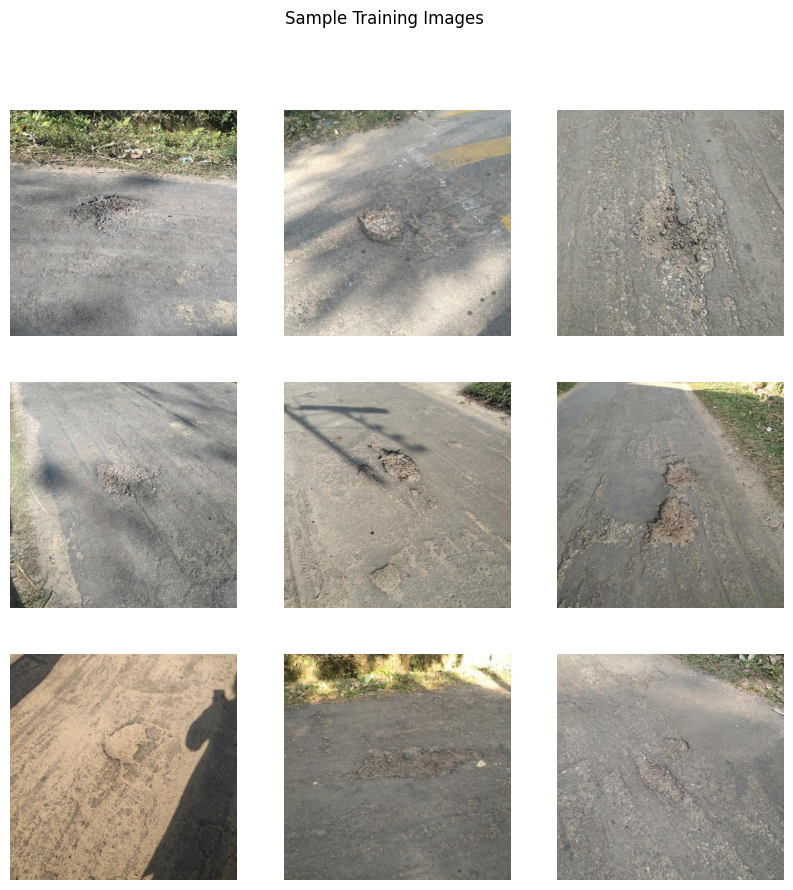

In [7]:
plt.figure(figsize=(10,10))

for i, img_path in enumerate(train_images[:9]):
    img = Image.open(img_path)
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Sample Training Images")
plt.show()


In [8]:
def show_image_with_labels(img_path):
    label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")

    img = Image.open(img_path)
    w, h = img.size

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())
                x1 = (xc - bw/2) * w
                y1 = (yc - bh/2) * h
                x2 = (xc + bw/2) * w
                y2 = (yc + bh/2) * h

                plt.gca().add_patch(
                    plt.Rectangle(
                        (x1, y1),
                        x2 - x1,
                        y2 - y1,
                        fill=False,
                        edgecolor="red",
                        linewidth=2
                    )
                )
    plt.show()


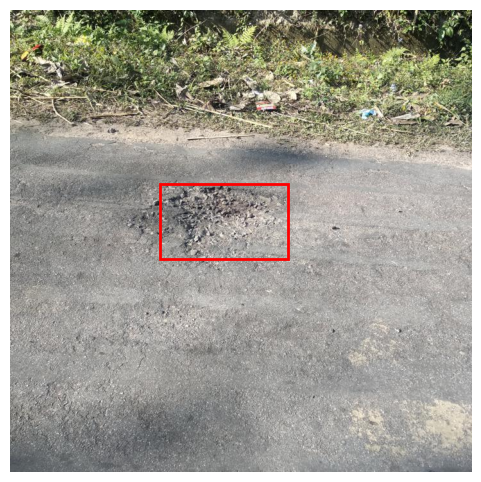

In [9]:
show_image_with_labels(train_images[0])


In [11]:
model = YOLO("yolov8m.pt")


In [12]:
results = model.train(
    data="pothole/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    optimizer="AdamW",
    lr0=1e-3,
    cos_lr=True,
    patience=10,
    augment=True
)


New https://pypi.org/project/ultralytics/8.4.6 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.5  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=pothole/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=Fa

KeyboardInterrupt: 

In [15]:
from ultralytics import YOLO

model = YOLO(r"C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets\runs\detect\train2\weights\best.pt")


In [16]:
metrics = model.val(
    data="pothole/data.yaml",
    split="test",
    imgsz=640,
    device=0
)

metrics


Ultralytics 8.4.5  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.70.8 ms, read: 2.60.7 MB/s, size: 34.6 KB)
val: Scanning C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets\pothole\test\labels... 67 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 67/67 245.6it/s 0.3s0.1s
val: New cache created: C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets\pothole\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 80.0s/it 6:401:0921
                   all         67        154      0.829      0.734      0.806       0.53
Speed: 73.0ms preprocess, 5889.7ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets\runs\detect\val


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001C911BD6E00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [17]:
results = model.predict(
    source="pothole/test/images",
    imgsz=640,
    conf=0.25,
    save=True
)



image 1/67 C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets\pothole\test\images\img-105_jpg.rf.3fe9dff3d1631e79ecb480ff403bcb86.jpg: 640x640 1 pothole, 6624.8ms
image 2/67 C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets\pothole\test\images\img-107_jpg.rf.2e40485785f6e5e2efec404301b235c2.jpg: 640x640 2 potholes, 4011.3ms
image 3/67 C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets\pothole\test\images\img-146_jpg.rf.61be25b3053a51f622a244980545df2b.jpg: 640x640 1 pothole, 2548.2ms
image 4/67 C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets\pothole\test\images\img-161_jpg.rf.211541e7178a4a93ec0680f26b905427.jpg: 640x640 1 pothole, 511.1ms
image 5/67 C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets\pothole\test\images\img-168_jpg.rf.af3590e07b06b43e91fa53990ff94af3.jpg: 640x640 2 potholes, 555.9ms
image 6/67 C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets\pothole\test\images\img-179_jpg.

In [18]:
model.predict(
    source=r"C:\Users\rushi\Downloads\istockphoto-531854696-612x612.jpg",
    imgsz=640,
    conf=0.3,
    show=True
)



image 1/1 C:\Users\rushi\Downloads\istockphoto-531854696-612x612.jpg: 448x640 2 potholes, 251.2ms
Speed: 5.8ms preprocess, 251.2ms inference, 3.8ms postprocess per image at shape (1, 3, 448, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'pothole'}
 obb: None
 orig_img: array([[[ 11,  70,  62],
         [ 29,  70,  65],
         [ 12,  39,  36],
         ...,
         [ 43, 153, 135],
         [ 32, 147, 127],
         [  9, 127, 102]],
 
        [[  0,  45,  35],
         [ 15,  62,  54],
         [ 19,  51,  46],
         ...,
         [ 26, 116, 103],
         [ 50, 138, 124],
         [ 54, 140, 122]],
 
        [[  0,  28,  13],
         [  0,  42,  29],
         [  0,  37,  27],
         ...,
         [ 55, 144, 135],
         [ 60, 160, 148],
         [ 51, 166, 149]],
 
        ...,
 
        [[ 90, 106, 112],
         [103, 119, 125],
         [102, 118, 124],
         ...,
         [213, 225, 231],
         [218, 230, 236],
         [212, 224, 230]],
 
        [[ 69,  85,  91],
         [ 87, 103, 109],
         [121, 137, 143],
         ...,
         [203, 21

In [19]:
image_path = r"C:\Users\rushi\Downloads\istockphoto-531854696-612x612.jpg"


In [20]:
results = model.predict(
    source=image_path,
    conf=0.25,     # confidence threshold
    iou=0.5,
    save=False,    # do not save, just display
    show=True      # IMPORTANT: displays image with boxes
)



image 1/1 C:\Users\rushi\Downloads\istockphoto-531854696-612x612.jpg: 448x640 2 potholes, 348.2ms
Speed: 4.7ms preprocess, 348.2ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)


(np.float64(-0.5), np.float64(611.5), np.float64(407.5), np.float64(-0.5))

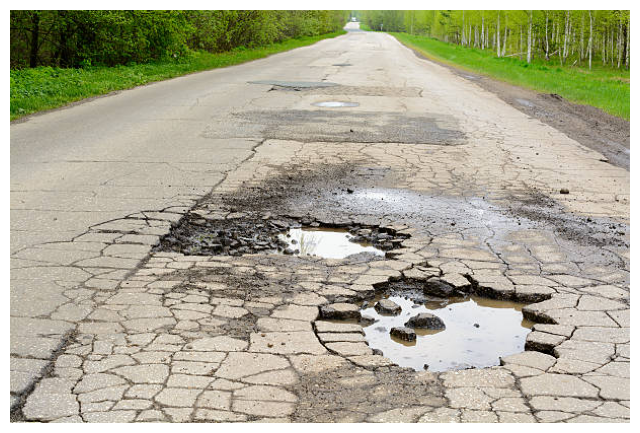

In [21]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(image_path)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")


(np.float64(-0.5), np.float64(611.5), np.float64(407.5), np.float64(-0.5))

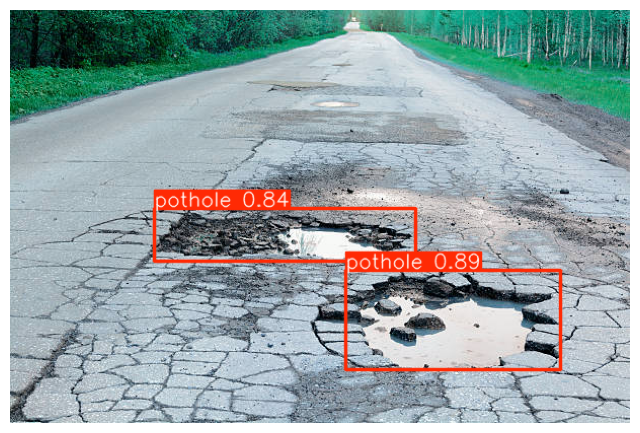

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO(r"C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets\runs\detect\train2\weights\best.pt")

image_path = r"C:\Users\rushi\Downloads\istockphoto-531854696-612x612.jpg"

results = model.predict(
    source=image_path,
    conf=0.15, 
    iou=0.5,
    save=False,
    verbose=False
)

annotated = results[0].plot()

plt.figure(figsize=(8,6))
plt.imshow(annotated)
plt.axis("off")


In [24]:
from ultralytics import YOLO

# Load trained model
model = YOLO(
    r"C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets\runs\detect\train2\weights\best.pt"
)

# Run prediction on video
model.predict(
    source=r"C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets\pothole_video.mp4",
    imgsz=640,
    conf=0.25,      # confidence threshold
    iou=0.5,
    device=0,
    save=True,
    save_txt=False,
    show=False
)



WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/692) C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets\pothole_video.mp4: 384x640 8 potholes, 892.0ms
video 1/1 (frame 2/692) C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets\pothole_video.mp4: 384x640 7 potholes, 874.7ms
video 1/1 (frame 3/692) C:\Users\rushi\OneDrive\Desktop\yolov8-pothole-detection\datasets\pothole_video.mp4: 384x640 8 potholes, 891.1ms
video 1/1 (frame 4/692) C:\Users\rushi\OneDrive\De

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'pothole'}
 obb: None
 orig_img: array([[[139, 130, 122],
         [163, 154, 146],
         [164, 155, 147],
         ...,
         [246, 243, 244],
         [246, 243, 244],
         [246, 243, 244]],
 
        [[197, 188, 180],
         [203, 194, 186],
         [169, 160, 152],
         ...,
         [246, 243, 244],
         [246, 243, 244],
         [246, 243, 244]],
 
        [[152, 143, 135],
         [177, 168, 160],
         [181, 172, 164],
         ...,
         [246, 243, 244],
         [246, 243, 244],
         [246, 243, 244]],
 
        ...,
 
        [[ 81,  93, 103],
         [ 75,  87,  97],
         [ 65,  77,  87],
         ...,
         [ 58,  78,  98],
         [ 60,  80, 100],
         [ 63,  83, 103]],
 
        [[ 65,  77,  87],
         [ 63,  75,  85],
         [ 58,  70,  80],
         ...,
         [ 64,  7